# Carousel Lens — Source 5 MAP

Single-source model targeting Source 5 (z_s=1.432, fold quad).  
Mass: EPL (La) + external shear  
Foreground: BCG SersicEllipse (lstsq)  
Source: SersicShapelets n_max=4 (lstsq), deflection_ratio=0.5619  

Reference: Urcelay et al. 2026 (arXiv:2602.16077)

## 1. Imports

In [1]:
import sys
sys.path.insert(0, '../sean-carousel/src')

import numpy as np
import optax
import jax
import jax.numpy as jnp
from astropy.io import fits
from astropy.visualization import simple_norm
from matplotlib import pyplot as plt
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import BackwardProbModel
from gigalens.jax.physical_model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles import mass, light
from gigalens.jax.profiles.light import sersic_shapelets as ss_mod
from gigalens.jax.prior import Prior, make_prior_and_model

tfd = tfp.distributions
plt.rcParams['figure.dpi'] = 150
print('Imports OK | devices:', jax.devices())

2026-05-22 12:36:17.824332: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779478577.989042 1491264 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779478578.033925 1491264 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779478578.369952 1491264 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779478578.370037 1491264 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779478578.370043 1491264 computation_placer.cc:177] computation placer alr

Imports OK | devices: [CudaDevice(id=0)]


## 2. Load Data

Image : (400, 400)  delta_pix=0.13966''/px
exp_time=597.7s  bkg_rms=0.003479 (binned)


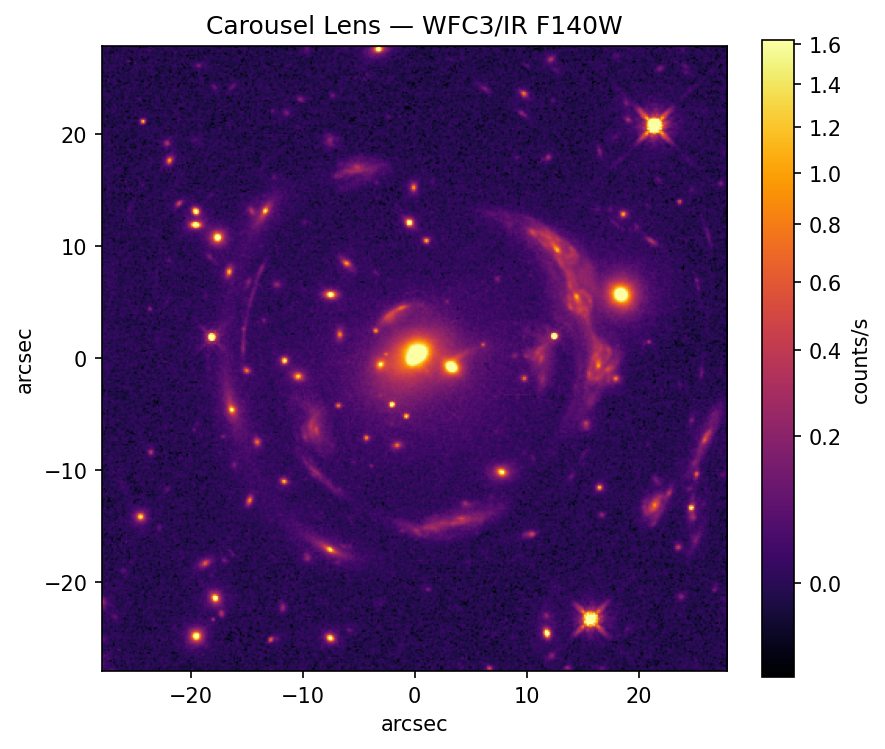

In [2]:
F140W_PATH = '../sean-carousel/model_data/f140w_img.fits'

with fits.open(F140W_PATH) as hdul:
    obs_native = hdul[0].data.astype(np.float32)
    hdr        = hdul[0].header
    exp_time   = float(hdr['EXPTIME'])
    bkg_rms    = float(hdr['BKGRMS'])

BIN = 2
h, w = obs_native.shape
obs = obs_native[:h//BIN*BIN, :w//BIN*BIN].reshape(h//BIN, BIN, w//BIN, BIN).mean(axis=(1, 3))

pc        = np.array([[hdr['PC1_1'], hdr['PC1_2']], [hdr['PC2_1'], hdr['PC2_2']]])
delta_pix = np.sqrt(np.sum(pc[0]**2)) * 3600 * BIN
num_pix   = obs.shape[0]
bkg_rms   = bkg_rms / BIN

extent = (
    -num_pix/2 * delta_pix, num_pix/2 * delta_pix,
    -num_pix/2 * delta_pix, num_pix/2 * delta_pix,
)

kernel = np.load('../carousel-lens/psf.npy').astype(np.float64)
kernel /= kernel.sum()

print(f'Image : {obs.shape}  delta_pix={delta_pix:.5f}\'\'/px')
print(f'exp_time={exp_time:.1f}s  bkg_rms={bkg_rms:.6f} (binned)')

norm = simple_norm(obs, 'sqrt', percent=99.5)
plt.figure(figsize=(6,6))
plt.imshow(obs, norm=norm, origin='lower', cmap='inferno', extent=extent)
plt.xlabel('arcsec'); plt.ylabel('arcsec')
plt.title('Carousel Lens — WFC3/IR F140W')
plt.colorbar(label='counts/s', fraction=0.046)
plt.tight_layout(); plt.show()

## 3. Priors

In [3]:
# Source 5: z_s=1.432 (fold quad), deflection_ratio = Dls/Ds = 0.5619
# FlatLCDM(H0=70, Om0=0.3), z_l=0.49
DR5 = 0.5619

# --- Mass: La (main cluster EPL) ---
la_prior = Prior(
    mass.epl.EPL(),
    dict(
        center_x = tfd.Normal(6.70, 1.0),
        center_y = tfd.Normal(4.80, 1.0),
        e1       = tfd.TruncatedNormal(0., 0.15, -0.4, 0.4),
        e2       = tfd.TruncatedNormal(0., 0.15, -0.4, 0.4),
        theta_E  = tfd.Normal(13.0, 2.0),
        gamma    = tfd.Uniform(1.5, 2.5),
    )
)

shear_prior = Prior(
    mass.shear.Shear(),
    dict(
        gamma1 = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
        gamma2 = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
    )
)

# --- Foreground: BCG ---
bcg_prior = Prior(
    light.sersic.SersicEllipse(use_lstsq=True),
    dict(
        center_x = tfd.Normal(6.70, 0.5),
        center_y = tfd.Normal(4.80, 0.5),
        e1       = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
        e2       = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
        n_sersic = tfd.Uniform(2., 8.),
        R_sersic = tfd.LogNormal(jnp.log(3.0), 0.3),
    )
)

# --- Source 5: SersicShapelets(n_max=4) ---
# depth=16, ~0.5 GB at 400px x 50 chains — fine.
# Source-plane center near La to stay inside caustic (fold quad -> slight offset).
src5_prior = Prior(
    ss_mod.SersicShapelets(n_max=4, use_lstsq=True, cosmo_sample=False),
    dict(
        deflection_ratio = DR5,
        center_x  = tfd.Normal(6.70, 1.0),
        center_y  = tfd.Normal(4.80, 1.0),
        e1        = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
        e2        = tfd.TruncatedNormal(0., 0.1, -0.3, 0.3),
        n_sersic  = tfd.Uniform(0.5, 5.),
        R_sersic  = tfd.LogNormal(jnp.log(1.0), 0.4),
        beta      = tfd.LogNormal(jnp.log(0.5), 0.4),
    )
)

prior, phys_model = make_prior_and_model(
    lenses     = [la_prior, shear_prior],
    sources    = [src5_prior],
    foreground = [bcg_prior],
)
print('Prior created.')
print(f'  Source params : {ss_mod.SersicShapelets(n_max=4, use_lstsq=True, cosmo_sample=False).params}')

Prior created.
  Source params : ['R_sersic', 'n_sersic', 'e1', 'e2', 'center_x', 'center_y', 'beta']


## 4. Simulator + Probabilistic Model

In [4]:
sim_config = SimulatorConfig(
    delta_pix   = delta_pix,
    num_pix     = num_pix,
    supersample = 1,
    kernel      = kernel,
)

# 20" circular mask centred on La — covers the full arc system
cx_px = num_pix / 2 + 6.70 / delta_pix
cy_px = num_pix / 2 + 4.80 / delta_pix
yy, xx = np.mgrid[:num_pix, :num_pix]
r_arcsec  = np.sqrt((xx - cx_px)**2 + (yy - cy_px)**2) * delta_pix
circ_mask = r_arcsec < 20.0

prob_model = BackwardProbModel(
    prior,
    obs,
    background_rms = bkg_rms,
    exp_time       = exp_time,
    mask           = circ_mask,
)

model_seq = ModellingSequence(phys_model, prob_model, sim_config)
print(f'Mask : {int(circ_mask.sum())} / {num_pix**2} pixels  ({100*circ_mask.mean():.1f}%)')
print('ModellingSequence ready.')

Mask : 64417 / 160000 pixels  (40.3%)
ModellingSequence ready.


## 5. MAP Optimization

In [5]:
NUM_STEPS = 5000
N_SAMPLES = 50

schedule  = optax.cosine_decay_schedule(init_value=3e-4, decay_steps=NUM_STEPS, alpha=1e-2)
optimizer = optax.adabelief(schedule, b1=0.95, b2=0.99)

start = prior.sample(N_SAMPLES, jax.random.PRNGKey(0))

print(f'Running MAP: {N_SAMPLES} chains x {NUM_STEPS} steps ...')
best, lps, chisq = model_seq.MAP(
    optimizer  = optimizer,
    n_samples  = N_SAMPLES,
    num_steps  = NUM_STEPS,
    start      = start,
    seed       = 0,
)
print(f'Done. Best reduced chi2 = {float(chisq[-1]):.4f}')

Running MAP: 50 chains x 5000 steps ...


  0%|          | 0/5000 [00:00<?, ?it/s]2026-05-22 12:36:56.293846: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng1{k2=4,k3=0} for conv %cudnn-conv.2 = (f32[50,17,400,400]{3,2,1,0}, u8[0]{0}) custom-call(%select.4319, %constant.8149), window={size=27x27 pad=13_13x13_13}, dim_labels=bf01_oi01->bf01, feature_group_count=17, custom_call_target="__cudnn$convForward", metadata={op_name="jit(run_map)/jit(main)/while/body/jit(loss)/jvp(jit(log_prob))/jit(log_like)/jit(stats_pixels)/jit(lstsq_simulate)/conv_general_dilated" source_file="/global/u1/c/chaseg/carousel-gigalens/../sean-carousel/src/gigalens/jax/simulator.py" source_line=265}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-05-22 12:36:59.706898: E external/xla/xla/service/slow_operat

Final Chi-squared: 19.06197
Done. Best reduced chi2 = 19.0620


## 6. Visualize

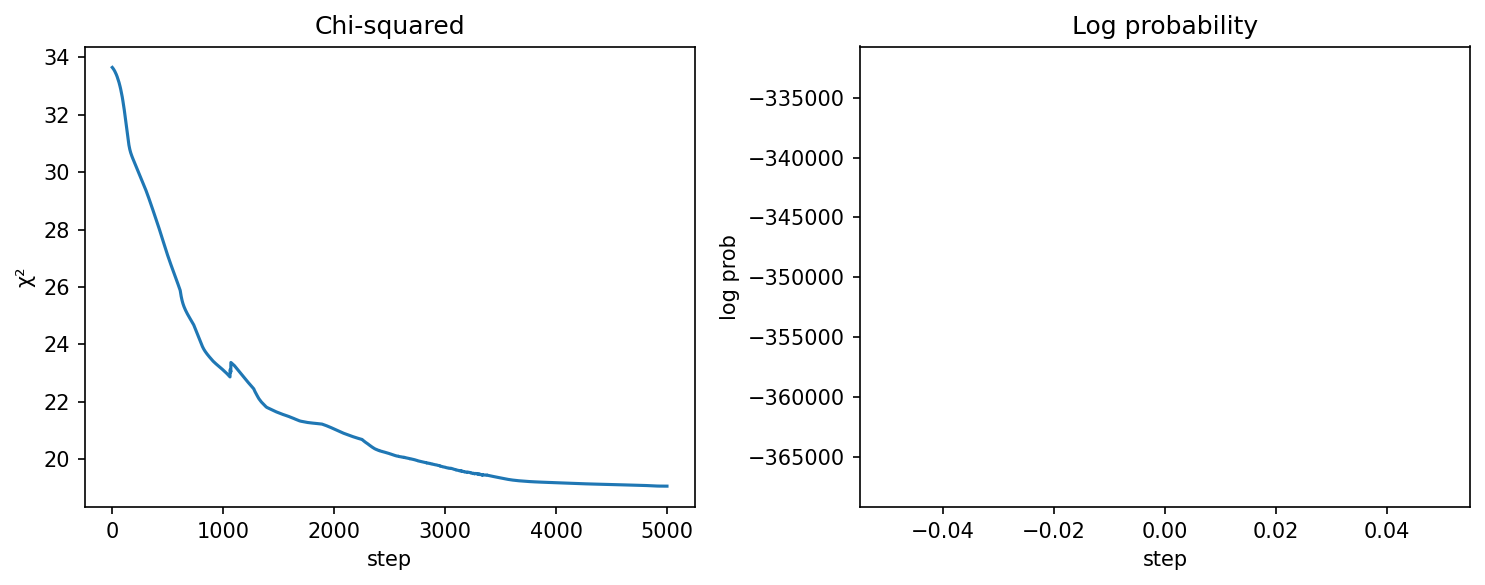

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(chisq); ax1.set(xlabel='step', ylabel='χ²', title='Chi-squared')
ax2.plot(lps);   ax2.set(xlabel='step', ylabel='log prob', title='Log probability')
plt.tight_layout(); plt.show()

2026-05-22 13:24:50.732080: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng46{k2=5,k5=3,k14=4} for conv %cudnn-conv.1 = (f32[1,17,400,400]{3,2,1,0}, u8[0]{0}) custom-call(%select.109, %constant.33), window={size=27x27 pad=13_13x13_13}, dim_labels=bf01_oi01->bf01, feature_group_count=17, custom_call_target="__cudnn$convForward", metadata={op_name="jit(lstsq_simulate)/jit(main)/conv_general_dilated" source_file="/global/u1/c/chaseg/carousel-gigalens/../sean-carousel/src/gigalens/jax/simulator.py" source_line=265}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-05-22 13:24:50.930408: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.1984185s
Trying algorithm eng46{k2=5,k5=3,k14=4} for conv %cudnn-conv.1 = (f32[1,17

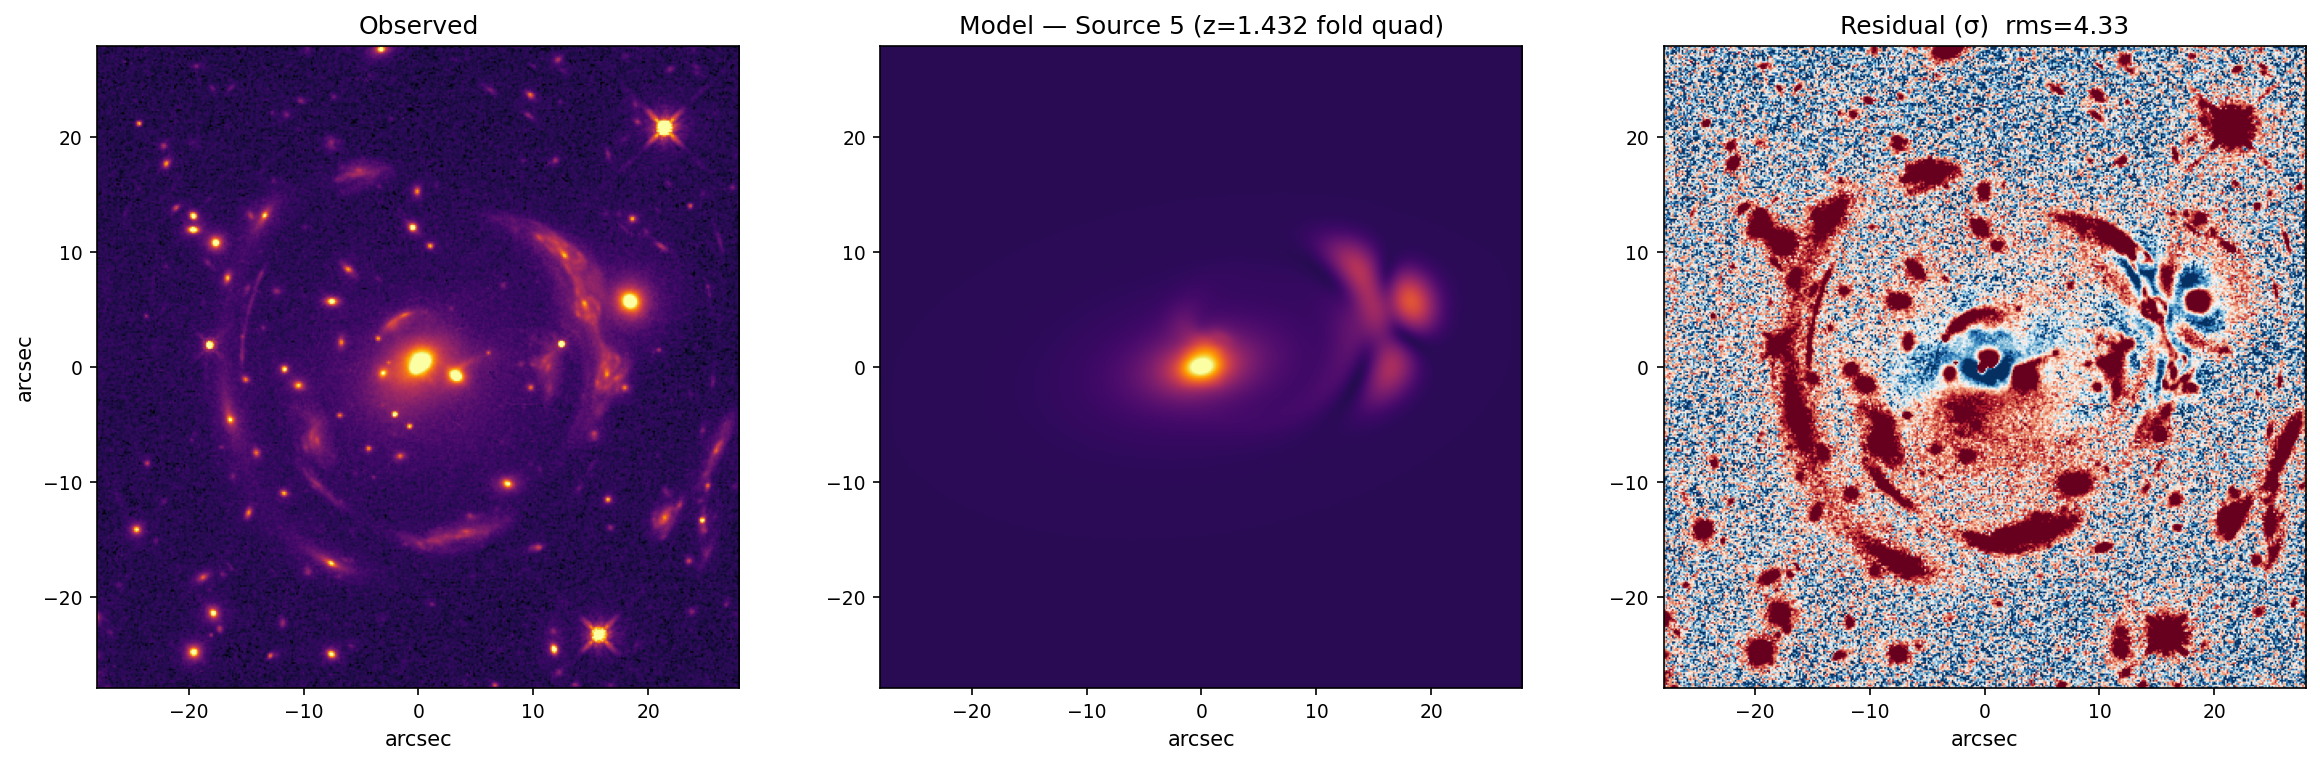

In [7]:
simulator   = LensSimulator(phys_model, sim_config, bs=1)
best_params = prob_model.bij.forward(list(best.T))
err_map     = np.array(prob_model.error_map)
mask        = np.array(prob_model.mask)
sim_im      = np.array(prob_model.simulate(simulator, best_params))
residual    = (obs - sim_im) / err_map

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
n = simple_norm(obs, 'sqrt', percent=99.5)

axes[0].imshow(obs,      norm=n, origin='lower', cmap='inferno', extent=extent)
axes[0].set(title='Observed', xlabel='arcsec', ylabel='arcsec')

axes[1].imshow(sim_im,   norm=n, origin='lower', cmap='inferno', extent=extent)
axes[1].set(title='Model — Source 5 (z=1.432 fold quad)', xlabel='arcsec')

axes[2].imshow(residual, origin='lower', cmap='RdBu_r', vmin=-5, vmax=5, extent=extent)
axes[2].set(title=f'Residual (σ)  rms={np.nanstd(residual[mask]):.2f}', xlabel='arcsec')

for ax in axes:
    ax.tick_params(labelsize=9)
plt.tight_layout()
import os; os.makedirs('models', exist_ok=True)
plt.savefig('models/src5_MAP.png', dpi=150)
plt.show()

## 7. Save + Best-fit Parameters

In [8]:
import os
os.makedirs('models', exist_ok=True)
np.save('models/src5_best.npy',  np.array(best))
np.save('models/src5_chisq.npy', np.array(chisq))
np.save('models/src5_lps.npy',   np.array(lps))

best_phys = prob_model.bij.forward(list(best.T))
print('Best-fit parameters:')
for section, vals in best_phys.items():
    for comp, params in vals.items():
        print(f'  [{section}/{comp}]')
        if isinstance(params, dict):
            for k, v in params.items():
                try:
                    print(f'    {k}: {float(np.array(v).ravel()[0]):.5f}')
                except Exception:
                    print(f'    {k}: {v}')
print('Saved to models/src5_*.npy')

Best-fit parameters:
  [source_light/0]
    n_sersic: 0.64106
    e2: 0.29896
    e1: 0.29928
    center_y: 3.01000
    center_x: 7.41800
    beta: 1.19919
    R_sersic: 1.70481
  [lens_mass/1]
    gamma2: 0.03915
    gamma1: 0.22636
  [lens_mass/0]
    theta_E: 12.30373
    gamma: 2.01920
    e2: -0.06135
    e1: 0.19503
    center_y: 2.25482
    center_x: 2.94243
  [lens_light/0]
    n_sersic: 2.52307
    e2: 0.09903
    e1: 0.29781
    center_y: -0.06983
    center_x: -0.06983
    R_sersic: 2.41459
Saved to models/src5_*.npy
